# Day 9 — Regression: the model the business actually pays for
### Real Estate Machine · Graduation Project

Everything so far has been preparation. Today the project answers its own question: **given a house,
what is it worth?**

Three things separate a defensible regression notebook from a student one, and none of them is the
algorithm:

1. **The target is transformed, so every reported error must be transformed back** — and the
   back-transform is not as innocent as it looks. Section 3.
2. **A score means nothing without a floor and a ceiling.** The floor is a model that does no work
   (section 4). The ceiling is what the professional AVM industry achieves (section 10).
3. **The average error hides the interesting part.** The model is not equally wrong everywhere, and
   *where* it is wrong is a business finding, not a footnote. Sections 8 and 9.

Today is the **baseline** day: linear models only, cross-validated, fully diagnosed. Day 10 adds
Random Forest and Gradient Boosting. Resist the urge to jump ahead — if you cannot say what a linear
model gets and why it fails where it fails, you cannot say whether the gradient booster earned its
extra complexity tomorrow.

---

## What you will produce

| Output | Why it exists |
|---|---|
| `Models/regression_baseline.pkl` | the fitted linear baseline, preprocessing included |
| `Models/baseline_results.csv` | the comparison table Day 10 appends to and Day 14 puts on a slide |
| `reports/figures/08_*.png` | residual diagnostics, error by segment, benchmark chart |
| A cited benchmark | the answer to *"is your error acceptable for a real business?"* |

---
## 1. Setup

Same clean data. Same split file. Same preprocessing module. Nothing is re-derived here, and that is
the point — Day 6 fixed the experiment so that Days 7 to 10 are comparable to each other.

In [19]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")

DATA = Path("..") / "Data"
MODELS = Path("..") / "Models"
FIGS = Path("..") / "reports" / "figures"
MODELS.mkdir(exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

sys.path.append(str((Path("..") / "app").resolve()))
import preprocessing as P

raw = pd.read_csv(DATA / "data_clean.csv", dtype={"zipcode": str})
df = P.engineer_features(raw)

split = pd.read_csv(DATA / "split_indices.csv", index_col="row")["split"]
is_train = (split.values == "train")
is_test = ~is_train

X = df[P.ALL_FEATURES]
y = np.log1p(df["price"])                 # the target, transformed

X_train, X_test = X[is_train], X[is_test]
y_train, y_test = y[is_train], y[is_test]

# Kept for the diagnostics in sections 8-9. NOT features.
price_test = np.expm1(y_test).values
segment_test = pd.read_csv(DATA / "data_clustered.csv")["segment"].values[is_test]

print(f"Train {X_train.shape[0]:,} x {X_train.shape[1]}   Test {X_test.shape[0]:,} x {X_test.shape[1]}")
print("Split reused from Day 6. Same rows as Days 7 and 8.")

Train 3,476 x 20   Test 869 x 20
Split reused from Day 6. Same rows as Days 7 and 8.


---
## 2. One metric function, defined once, used everywhere

Write the scoring code **before** the modelling code. Two reasons:

- Every model gets scored identically. A comparison table where one row was computed slightly
  differently is worse than no table.
- It forces you to decide what you are measuring before you have a number you want to be proud of.

The metrics, and who each one is for:

| Metric | Space | Who reads it |
|---|---|---|
| $R^2$ | log | the examiner; "what share of the variation is explained" |
| RMSE (log) | log | you, for optimisation; not interpretable to anyone else |
| MAE | dollars | a manager, roughly: "typical miss in money" |
| RMSE | dollars | risk: it squares errors, so a few huge misses dominate it |
| **MedAPE** | percent | **the headline.** the typical house is off by this much, in % |
| MAPE | percent | the mean version — dragged up by a small number of bad misses |
| PPE10 / PPE20 | percent | share of houses valued within 10% / 20% of the sale price |

**MedAPE is the headline metric of this project.** A manager does not think "$105,000 of error"; a
manager thinks "12% off". And the median version, not the mean, because Day 3 showed this price
distribution has a long right tail — the mean of a percentage error is pulled around by a handful of
houses in exactly the way the median is not.

PPE10 comes from the appraisal industry, where it is the standard companion to MedAPE: the share of
valuations landing within ±10% of the true price. It answers a question MedAPE cannot — *how often
is this usable?* — and section 10 has a published threshold to compare it against.

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def score(y_true_log, y_pred_log, label):
    # Every metric this project reports, from one pair of log-space vectors.
    true_d = np.expm1(y_true_log)
    pred_d = np.expm1(y_pred_log)
    ape = np.abs(pred_d - true_d) / true_d

    return {
        "model": label,
        "R2_log": r2_score(y_true_log, y_pred_log),
        "RMSE_log": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "MAE_$": mean_absolute_error(true_d, pred_d),
        "RMSE_$": np.sqrt(mean_squared_error(true_d, pred_d)),
        "MedAPE_%": 100 * np.median(ape),
        "MAPE_%": 100 * ape.mean(),
        "PPE10_%": 100 * (ape <= 0.10).mean(),
        "PPE20_%": 100 * (ape <= 0.20).mean(),
    }


def show(rows):
    t = pd.DataFrame(rows).set_index("model")
    return t.style.format({
        "R2_log": "{:.4f}", "RMSE_log": "{:.4f}",
        "MAE_$": "${:,.0f}", "RMSE_$": "${:,.0f}",
        "MedAPE_%": "{:.2f}%", "MAPE_%": "{:.2f}%",
        "PPE10_%": "{:.1f}%", "PPE20_%": "{:.1f}%",
    })


results = []
print("Scoring function defined. Every number below comes through it.")

Scoring function defined. Every number below comes through it.


---
## 3. The back-transform, and the bias nobody mentions

The model predicts $\log(1+\text{price})$. To report anything in dollars you invert with
`np.expm1()`. Almost every tutorial stops there. It is not quite right, and knowing why is a genuine
technical answer.

**The problem.** The model is trained to predict the *mean of the log*. But

$$\mathbb{E}[\exp(Z)] \;\neq\; \exp(\mathbb{E}[Z])$$

for any random variable with spread — Jensen's inequality. Exponentiating an unbiased prediction of
the log gives you something closer to the **median** price than the mean price, and it is
systematically low as an estimate of the mean.

**The textbook fix** is Duan's *smearing estimator*: multiply the back-transformed prediction by the
average of the exponentiated training residuals,

$$\hat{s} = \frac{1}{n}\sum_i \exp(e_i), \qquad e_i = y_i - \hat{y}_i \ \text{(in log space)}$$

Run it. Then look at what actually happens to the bias — and report what you see, not what the
formula promised.

In [21]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

probe = Pipeline([("pre", P.build_preprocessor(smoothing=20)), ("model", Ridge(alpha=1.0))])
probe.fit(X_train, y_train)

resid_train = y_train - probe.predict(X_train)
smearing = float(np.mean(np.exp(resid_train)))
print(f"Duan smearing factor s = {smearing:.4f}   (s = 1 would mean no correction needed)")

pred_log = probe.predict(X_test)
naive = np.expm1(pred_log)
smeared = (np.expm1(pred_log) + 1) * smearing - 1
truth = price_test

for name, pred in [("naive  expm1(pred)", naive), ("smeared  x s", smeared)]:
    ape = np.abs(pred - truth) / truth
    print(f"{name:<20} mean bias = ${np.mean(pred - truth):>9,.0f}   "
          f"MedAPE = {100 * np.median(ape):5.2f}%   MAPE = {100 * ape.mean():5.2f}%")

Duan smearing factor s = 1.0231   (s = 1 would mean no correction needed)
naive  expm1(pred)   mean bias = $   11,670   MedAPE = 12.53%   MAPE = 16.95%
smeared  x s         mean bias = $   24,902   MedAPE = 12.69%   MAPE = 17.46%


### Read this result honestly — it did not go the way the theory says

The smearing factor comes out just above 1, so the correction *raises* every prediction by a couple
of percent. And the naive back-transform was **already over-predicting on average** — its mean bias
is positive, not negative. Applying the correction therefore makes the average bias worse, and
MedAPE worse with it.

Why the theory and the data disagree here: Duan's estimator assumes the log-space residuals are
independent of the fitted value. Section 8 will show they are not — the model over-predicts cheap
houses badly and under-predicts expensive ones, so a single multiplicative constant applied to every
house cannot fix a bias whose *sign changes* across the price range.

**The decision, and the sentence to say out loud:**

> I use the plain `expm1` back-transform. I tested Duan's smearing estimator, which is the standard
> correction for retransformation bias, and it made both the mean bias and the median percentage
> error worse on my test set — because the residuals are not independent of the fitted value, which
> is the assumption the estimator needs. I report the median absolute percentage error as my
> headline, and the median is the statistic the plain back-transform is naturally consistent with.

An examiner who asks "did you correct for retransformation bias?" is expecting either a blank look
or a yes. A measured "yes, I tested it, here is why I did not use it" is a different grade.

---
## 4. The floors — what does no model at all achieve?

Two baselines, both legitimate businesses in their own right:

1. **The global median.** Quote the same price for every house. This is the honest zero point of
   $R^2$, and its MedAPE tells you the raw spread of the market.
2. **The zip code median.** Quote the median price of the house's zip code. This is what a
   competent estate agent does in ten seconds with no model, and it is the *real* competitor. A
   machine learning model that cannot comfortably beat it has not earned its deployment.

The second baseline is computed from **training rows only** — a median is a statistic learned from
data, and Day 6's rule does not stop applying just because the model is simple.

In [22]:
results.append(score(y_test, np.full(len(y_test), y_train.median()), "Baseline: global median"))
zip_median = y_train.groupby(X_train["zipcode"]).median()
zip_pred = X_test["zipcode"].map(zip_median).fillna(y_train.median()).values
results.append(score(y_test, zip_pred, "Baseline: zipcode median"))
show(results)

,R2_log,RMSE_log,MAE_$,RMSE_$,MedAPE_%,MAPE_%,PPE10_%,PPE20_%
model,,,,,,,,
Baseline: global median,-0.0043,0.5163,"$226,109","$368,153",34.40%,41.98%,14.2%,31.2%
Baseline: zipcode median,0.5272,0.3542,"$155,642","$282,553",21.00%,26.22%,25.5%,48.3%


The global median scores $R^2 \approx 0$ — as it must, by the definition of $R^2$ — and is off by
roughly a third on the typical house.

The zip code median is the number to remember: it explains over half the variance in log price with
**one `groupby`**. Day 4 said location was the strongest driver after size; this is that finding
expressed as a model. Every point of $R^2$ your regression adds beyond this line is what the other
nineteen features and the machine learning are actually worth.

---
## 5. Linear, Ridge and Lasso — and why the preprocessor goes inside the pipeline

Three linear models on the same 20 features:

- **Linear Regression** — no penalty. Minimises squared error, nothing else.
- **Ridge** — adds a penalty on the *sum of squared* coefficients. Shrinks correlated features
  toward each other instead of letting one take a huge positive coefficient and its twin a huge
  negative one. Day 6 removed the *exact* collinearity; `sqft_living` and `log_sqft_living` are
  still very strongly related, and Ridge is the reason that is now harmless.
- **Lasso** — penalises the *sum of absolute* coefficients, which drives some of them to exactly
  zero. It performs feature selection as a side effect, and section 7 reads which features it drops.

Every one of them is wrapped in a `Pipeline` **with the preprocessor inside it**. This is not tidiness.
`cross_val_score` clones the whole pipeline and refits it on each training fold, so the
`StandardScaler` and the `SmoothedTargetEncoder` are re-learned five times, never once seeing the
fold they are scored on. Fit the preprocessor outside and cross-validate the model alone, and every
fold score is contaminated by the fold it is supposed to be testing on.

In [23]:
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1)": Ridge(alpha=1.0),
    "Lasso (alpha=0.001)": Lasso(alpha=0.001),
}

cv_rows = []
for name, model in candidates.items():
    pipe = Pipeline([("pre", P.build_preprocessor(smoothing=20)), ("model", model)])
    cv = cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
    pipe.fit(X_train, y_train)
    row = score(y_test, pipe.predict(X_test), name)
    row["CV_R2_train"] = cv.mean()
    row["CV_sd"] = cv.std()
    cv_rows.append(row)
    results.append(row)

pd.DataFrame(cv_rows).set_index("model")[["CV_R2_train", "CV_sd", "R2_log", "MedAPE_%", "PPE10_%"]].round(4)

,CV_R2_train,CV_sd,R2_log,MedAPE_%,PPE10_%
model,,,,,
Linear Regression,0.8297,0.0138,0.8257,12.5340,40.6214
Ridge (alpha=1),0.8297,0.0138,0.8258,12.5314,40.5063
Lasso (alpha=0.001),0.8304,0.0137,0.8267,12.7713,40.8516


In [24]:
show(results)

,R2_log,RMSE_log,MAE_$,RMSE_$,MedAPE_%,MAPE_%,PPE10_%,PPE20_%,CV_R2_train,CV_sd
model,,,,,,,,,,
Baseline: global median,-0.0043,0.5163,"$226,109","$368,153",34.40%,41.98%,14.2%,31.2%,nan,nan
Baseline: zipcode median,0.5272,0.3542,"$155,642","$282,553",21.00%,26.22%,25.5%,48.3%,nan,nan
Linear Regression,0.8257,0.2151,"$105,231","$300,235",12.53%,16.95%,40.6%,69.9%,0.829662,0.013776
Ridge (alpha=1),0.8258,0.2150,"$105,134","$298,558",12.53%,16.95%,40.5%,70.0%,0.829719,0.013768
Lasso (alpha=0.001),0.8267,0.2144,"$103,517","$274,904",12.77%,16.87%,40.9%,69.9%,0.830353,0.013702


### What this table says, in one paragraph

The three linear models are **indistinguishable**. Their cross-validated $R^2$ agrees to three
decimal places and their test MedAPE differs by less than a quarter of a percentage point — far
inside the fold-to-fold standard deviation printed above.

That is a result, and the correct way to present it is:

> Regularisation made no measurable difference on this problem. That is expected: I removed the
> exact collinearity on Day 6, and with 3,476 training rows and only 20 features the model is not
> in a regime where it can overfit badly enough for a penalty to rescue it. I report Ridge as the
> baseline because it is the safest of the three to deploy, not because it won.

Compare that with what all three achieve over the zip-code baseline. That gap — roughly 30 points of
$R^2$ and a third off the typical percentage error — is the actual contribution of the modelling.

---
## 6. Choosing the penalty properly — cross-validation and the one-standard-error rule

`alpha=1.0` was a guess. Replace it with a searched value, using the same discipline Day 6 used for
the smoothing constant:

- Search on the **training set only**, by cross-validation. The test set does not vote on
  hyperparameters.
- Apply the **one-standard-error rule**: among all values whose CV score is within one standard
  error of the best, choose the most heavily regularised one. Differences smaller than the noise are
  not differences, and the simpler model is the one that survives contact with new data.

In [25]:
from sklearn.model_selection import GridSearchCV


def tune(model, grid, label):
    gs = GridSearchCV(Pipeline([("pre", P.build_preprocessor(smoothing=20)), ("model", model)]),
                      grid, cv=kf, scoring="r2", n_jobs=-1, return_train_score=False).fit(X_train, y_train)

    t = pd.DataFrame(gs.cv_results_)[["param_model__alpha", "mean_test_score", "std_test_score"]]
    t = t.rename(columns={"param_model__alpha": "alpha", "mean_test_score": "cv_r2",
                          "std_test_score": "sd"})
    t["se"] = t["sd"] / np.sqrt(kf.get_n_splits())
    best = t.loc[t["cv_r2"].idxmax()]
    threshold = best["cv_r2"] - best["se"]
    t["within_1se"] = t["cv_r2"] >= threshold
    chosen = t.loc[t["within_1se"], "alpha"].max()      # most regularised model that is still fine

    print(f"{label}: best alpha = {best['alpha']}, CV R2 = {best['cv_r2']:.4f}; "
          f"one-SE threshold = {threshold:.4f}")
    print(f"{label}: chosen alpha = {chosen}  (most regularised within one SE)")
    print(t.round(5).to_string(index=False), "\n")
    return float(chosen), t


ridge_alpha, ridge_grid = tune(Ridge(), {"model__alpha": [0.01, 0.1, 1, 10, 30, 100]}, "Ridge")
lasso_alpha, lasso_grid = tune(Lasso(max_iter=10000),
                               {"model__alpha": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]}, "Lasso")

Ridge: best alpha = 30.0, CV R2 = 0.8302; one-SE threshold = 0.8240
Ridge: chosen alpha = 100.0  (most regularised within one SE)
   alpha  cv_r2     sd     se  within_1se
  0.0100 0.8297 0.0138 0.0062        True
  0.1000 0.8297 0.0138 0.0062        True
  1.0000 0.8297 0.0138 0.0062        True
 10.0000 0.8300 0.0137 0.0061        True
 30.0000 0.8302 0.0137 0.0061        True
100.0000 0.8301 0.0137 0.0061        True 

Lasso: best alpha = 0.001, CV R2 = 0.8304; one-SE threshold = 0.8242
Lasso: chosen alpha = 0.01  (most regularised within one SE)
 alpha  cv_r2     sd     se  within_1se
0.0000 0.8297 0.0138 0.0062        True
0.0001 0.8298 0.0138 0.0062        True
0.0010 0.8304 0.0137 0.0061        True
0.0100 0.8248 0.0148 0.0066        True
0.1000 0.7404 0.0153 0.0068       False 



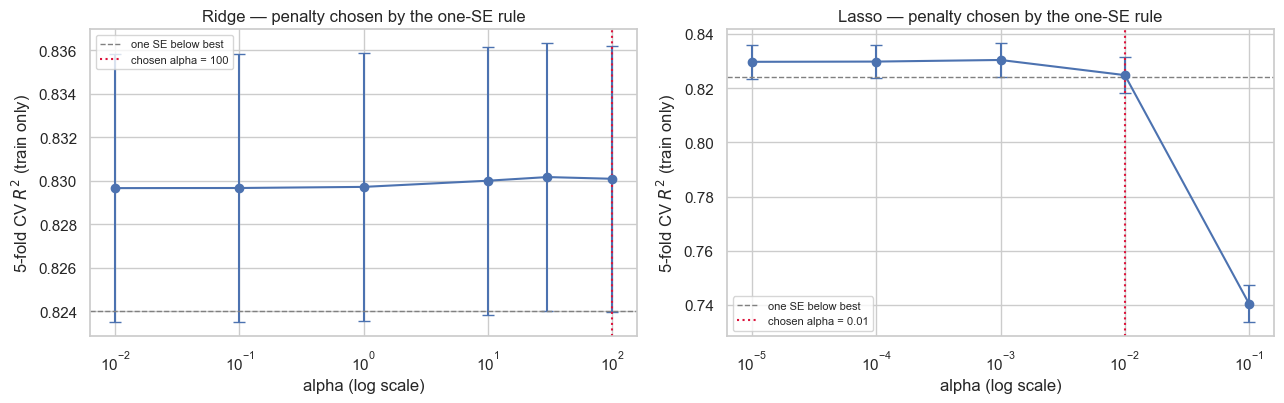

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for a, (t, chosen, name) in zip(ax, [(ridge_grid, ridge_alpha, "Ridge"),
                                     (lasso_grid, lasso_alpha, "Lasso")]):
    a.errorbar(t["alpha"].astype(float), t["cv_r2"], yerr=t["se"], marker="o", capsize=4)
    a.set_xscale("log")
    a.axhline(t.loc[t["cv_r2"].idxmax(), "cv_r2"] - t.loc[t["cv_r2"].idxmax(), "se"],
              ls="--", c="grey", lw=1, label="one SE below best")
    a.axvline(chosen, ls=":", c="crimson", lw=1.5, label=f"chosen alpha = {chosen:g}")
    a.set_xlabel("alpha (log scale)"); a.set_ylabel("5-fold CV $R^2$ (train only)")
    a.set_title(f"{name} — penalty chosen by the one-SE rule")
    a.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGS / "08_alpha_selection.png", dpi=150)
plt.show()

In [27]:
final = Pipeline([("pre", P.build_preprocessor(smoothing=20)),
                  ("model", Ridge(alpha=ridge_alpha))]).fit(X_train, y_train)

lasso_final = Pipeline([("pre", P.build_preprocessor(smoothing=20)),
                        ("model", Lasso(alpha=lasso_alpha, max_iter=10000))]).fit(X_train, y_train)

results.append(score(y_test, final.predict(X_test), f"Ridge (alpha={ridge_alpha:g}, tuned)"))
results.append(score(y_test, lasso_final.predict(X_test), f"Lasso (alpha={lasso_alpha:g}, tuned)"))

pred_log = final.predict(X_test)
pred_price = np.expm1(pred_log)

show(results)

,R2_log,RMSE_log,MAE_$,RMSE_$,MedAPE_%,MAPE_%,PPE10_%,PPE20_%,CV_R2_train,CV_sd
model,,,,,,,,,,
Baseline: global median,-0.0043,0.5163,"$226,109","$368,153",34.40%,41.98%,14.2%,31.2%,nan,nan
Baseline: zipcode median,0.5272,0.3542,"$155,642","$282,553",21.00%,26.22%,25.5%,48.3%,nan,nan
Linear Regression,0.8257,0.2151,"$105,231","$300,235",12.53%,16.95%,40.6%,69.9%,0.829662,0.013776
Ridge (alpha=1),0.8258,0.2150,"$105,134","$298,558",12.53%,16.95%,40.5%,70.0%,0.829719,0.013768
Lasso (alpha=0.001),0.8267,0.2144,"$103,517","$274,904",12.77%,16.87%,40.9%,69.9%,0.830353,0.013702
"Ridge (alpha=100, tuned)",0.8270,0.2143,"$103,010","$265,312",12.52%,16.83%,41.0%,69.6%,nan,nan
"Lasso (alpha=0.01, tuned)",0.8222,0.2172,"$104,440","$279,029",13.02%,16.95%,40.4%,69.5%,nan,nan



Two things to notice, and both belong in what you say rather than in a footnote.

**Every Ridge alpha in the grid is within one standard error of the best**, so the rule picks the
largest value offered — the CV curve is essentially flat across four orders of magnitude. For Lasso
the rule steps one notch past the best-scoring value, which costs a fraction of a point of $R^2$ and
drops several more features to exactly zero.

**The tuned test scores barely move.** That flatness is the honest headline: on this dataset the
penalty is not where the performance lives. Report the tuned alpha because choosing it by a stated
rule is better practice than guessing — not because it bought you anything measurable.

---
## 7. Reading the coefficients — including one that will be challenged

The features were standardised, so each coefficient is the change in $\log(1+\text{price})$ per
**one standard deviation** of that feature, holding the others fixed. Because the target is a log,
$\exp(\beta) - 1$ converts a coefficient into an approximate **percentage effect on price**, which
is the form to put on a slide.

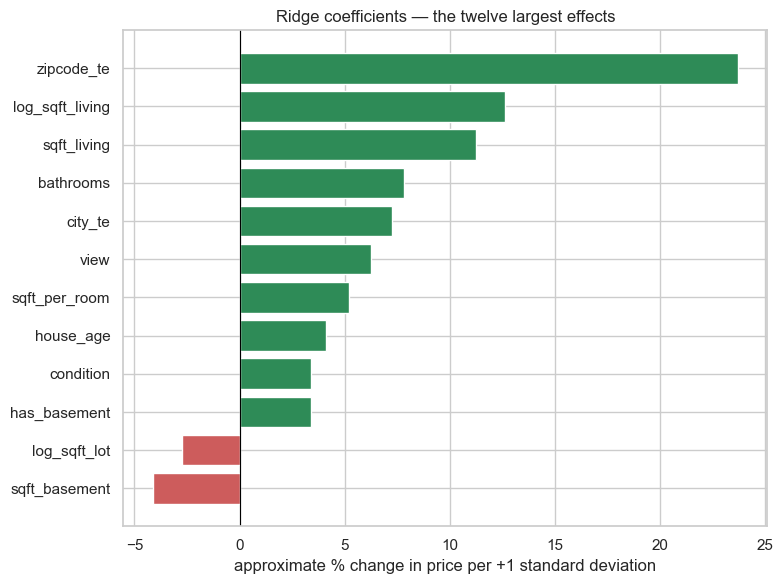

,coef_log,pct_effect
zipcode_te,0.2127,23.7022
log_sqft_living,0.1187,12.6068
sqft_living,0.1067,11.2585
bathrooms,0.0752,7.8134
city_te,0.0698,7.2275
view,0.0604,6.2291
sqft_per_room,0.0505,5.1825
sqft_basement,-0.0421,-4.1265
house_age,0.0402,4.0991
condition,0.0335,3.4025


In [28]:
names = P.feature_names(final.named_steps["pre"])
coef = pd.Series(final.named_steps["model"].coef_, index=names)

effect = (pd.DataFrame({"coef_log": coef, "pct_effect": 100 * (np.exp(coef) - 1)})
            .sort_values("coef_log", key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(8, 6))
top = effect.head(12).sort_values("pct_effect")
ax.barh(top.index, top["pct_effect"],
        color=np.where(top["pct_effect"] >= 0, "seagreen", "indianred"))
ax.axvline(0, c="black", lw=0.8)
ax.set_xlabel("approximate % change in price per +1 standard deviation")
ax.set_title("Ridge coefficients — the twelve largest effects")
fig.tight_layout()
fig.savefig(FIGS / "08_coefficients.png", dpi=150)
plt.show()

effect.round(4)

In [29]:
zeroed = [n for n, v in zip(names, lasso_final.named_steps["model"].coef_) if v == 0]
print(f"Lasso kept {len(names) - len(zeroed)} of {len(names)} features.")
print("Dropped entirely:", zeroed if zeroed else "none")

Lasso kept 14 of 20 features.
Dropped entirely: ['bedrooms', 'sqft_lot', 'years_since_reno', 'has_basement', 'basement_ratio', 'log_sqft_lot']


### Three things to say about this chart before anyone asks

**1. The target-encoded zip code is the largest single effect.** Location beats size, which confirms
Day 4 and is the finding the business report already leads with. Add the caveat that this column was
*built* from training prices, which is why Day 6 spent so long making it leakage-safe — an examiner
who spots that it is a price-derived feature should hear you explain the out-of-fold construction
before they have to ask.

**2. `sqft_living` and `log_sqft_living` share the effect between them.** Two versions of the same
measurement, both retained, both with positive coefficients — so neither number alone is "the effect
of size". Quote them together, or quote the total. This is the honest cost of keeping both, and it
is precisely what Ridge's penalty is managing.

**3. `house_age` comes out positive — older houses predicted *more* expensive, holding size, zip
code and condition fixed.** This is the coefficient you will be challenged on. Do not explain it
away. The defensible reading:

> Within a zip code and at a fixed size, the older stock in this dataset sits in the established
> inner neighbourhoods, while the newest stock sits on the suburban edge of the same postal areas.
> Age is acting as a proxy for micro-location that my features cannot capture directly, because the
> dataset has no coordinates and no lot-quality grade. It is a correlation inside my feature set,
> not a claim that ageing a house adds value.

That is what a coefficient in an observational model is: a conditional association. Saying so is the
single clearest signal that you understand regression rather than having run it.

---
## 8. Residual diagnostics — four plots, four separate questions

Never present a regression without these. Each panel answers one specific question, and at least one
of them is going to show a problem.

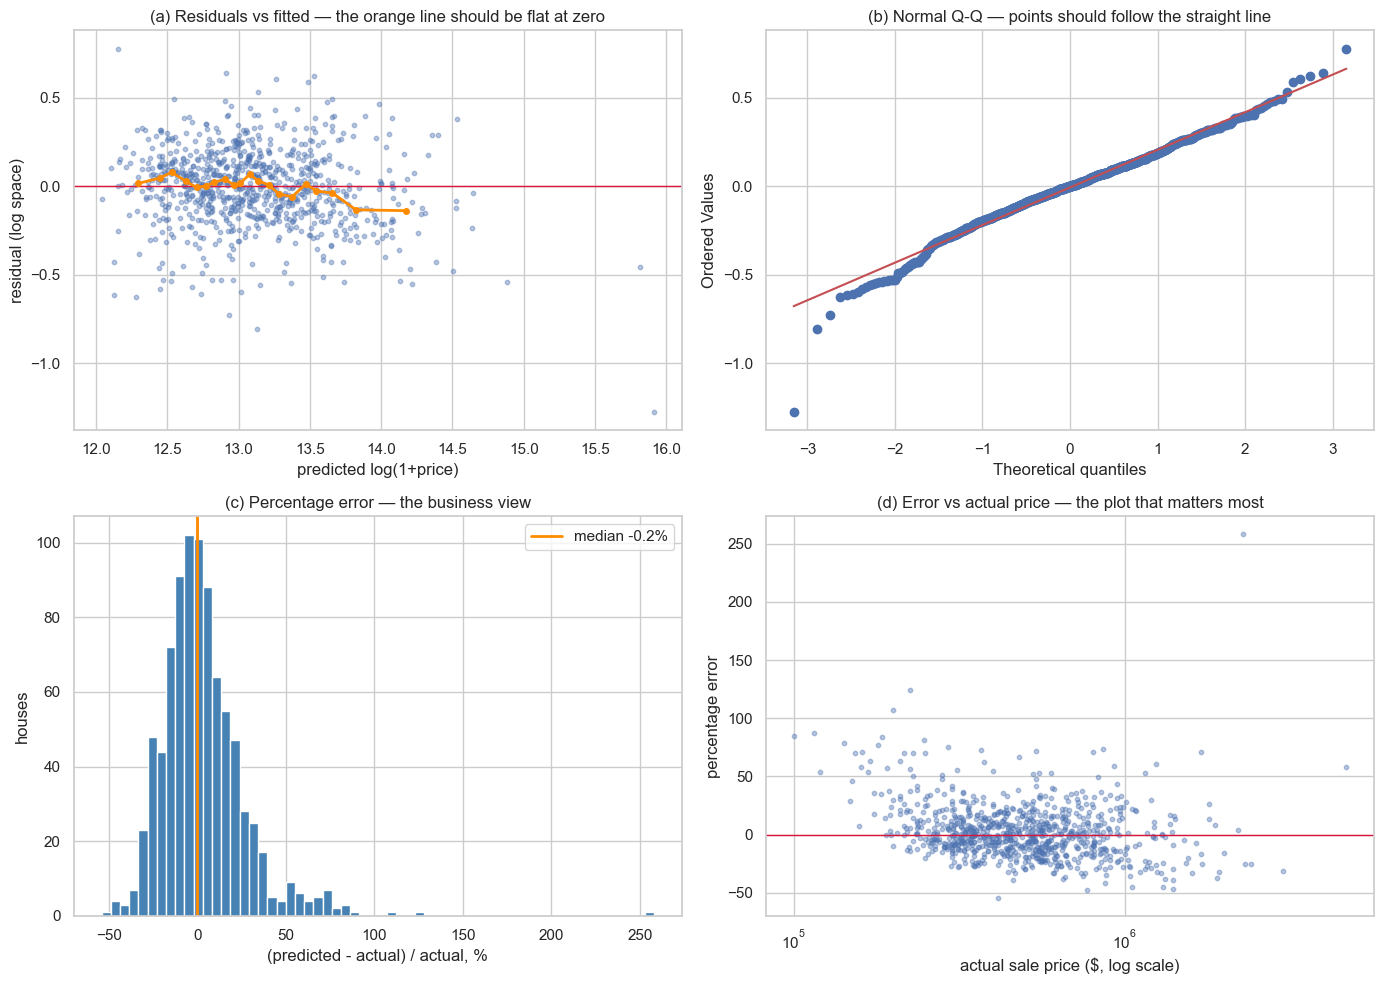

Residual skewness : -0.435   (0 = symmetric)
Residual kurtosis : +1.894   (0 = normal tails)


In [30]:
from scipy import stats

resid = y_test.values - pred_log                       # log space
pct_err = (pred_price - price_test) / price_test       # signed percentage error

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# (a) residuals vs fitted -- is the relationship linear, is the spread constant?
ax[0, 0].scatter(pred_log, resid, s=10, alpha=0.4)
ax[0, 0].axhline(0, c="crimson", lw=1)
# A trend line without extra dependencies: median residual in 20 equal-count bins.
bin_id = pd.qcut(pred_log, 20, labels=False, duplicates="drop")
trend = (pd.DataFrame({"b": bin_id, "x": pred_log, "r": resid})
           .groupby("b").agg(x=("x", "median"), r=("r", "median")))
ax[0, 0].plot(trend["x"], trend["r"], color="darkorange", lw=2, marker="o", ms=4)
ax[0, 0].set_xlabel("predicted log(1+price)"); ax[0, 0].set_ylabel("residual (log space)")
ax[0, 0].set_title("(a) Residuals vs fitted — the orange line should be flat at zero")

# (b) QQ plot -- are the residuals normal?
stats.probplot(resid, dist="norm", plot=ax[0, 1])
ax[0, 1].set_title("(b) Normal Q-Q — points should follow the straight line")

# (c) distribution of the percentage error -- what a manager sees
ax[1, 0].hist(100 * pct_err, bins=60, color="steelblue")
ax[1, 0].axvline(0, c="crimson", lw=1)
ax[1, 0].axvline(100 * np.median(pct_err), c="darkorange", lw=2,
                 label=f"median {100 * np.median(pct_err):+.1f}%")
ax[1, 0].set_xlabel("(predicted - actual) / actual, %"); ax[1, 0].set_ylabel("houses")
ax[1, 0].set_title("(c) Percentage error — the business view"); ax[1, 0].legend()

# (d) error vs actual price -- where in the market does it fail?
ax[1, 1].scatter(price_test, 100 * pct_err, s=10, alpha=0.4)
ax[1, 1].axhline(0, c="crimson", lw=1)
ax[1, 1].set_xscale("log")
ax[1, 1].set_xlabel("actual sale price ($, log scale)"); ax[1, 1].set_ylabel("percentage error")
ax[1, 1].set_title("(d) Error vs actual price — the plot that matters most")

fig.tight_layout()
fig.savefig(FIGS / "08_residual_diagnostics.png", dpi=150)
plt.show()

print(f"Residual skewness : {stats.skew(resid):+.3f}   (0 = symmetric)")
print(f"Residual kurtosis : {stats.kurtosis(resid):+.3f}   (0 = normal tails)")

### What you should be seeing, and what to say about it

**(a)** The orange line is the median residual in each of twenty equal-sized bins of the fitted
value — a trend line built from the data rather than from an extra library. It sits close to zero
across most of the range and drifts below zero at the top. The scatter is also wider at the low end
than at the high end: the log transform fixed most, but not all, of the non-constant error spread.

> **A trap worth knowing about before someone sets it for you.** Panel (a) conditions on the
> **prediction**; panel (d) conditions on the **actual price**. They will look like they contradict
> each other, and they do not. Among houses the model *calls* expensive, it turns out to have been a
> little optimistic. Among houses that *actually sold* expensive, it was too low. Both are regression
> to the mean seen from opposite ends, and a student who can say that sentence has understood
> residual plots rather than memorised them.

**(b)** The middle of the Q-Q plot follows the line and both tails fall away from it. The residuals
are mildly left-skewed with heavier-than-normal tails. Do not run a normality test and report the
p-value: with 869 points, any test rejects normality for deviations far too small to matter. Read
the plot and describe the shape instead.

**(c)** The percentage error is centred near zero but is not symmetric — a long right tail of houses
the model over-values.

**(d)** This is the one to put on a slide. The error is not constant across the market: the cheapest
houses are systematically **over**-valued and the most expensive systematically **under**-valued.
Quantify it rather than eyeballing it.

        houses   median_price  median_signed_error  MedAPE
decile                                                    
1           87   223,000.0000              19.7200 19.7200
2           88   295,000.0000              -0.2500  9.6900
3           87   335,000.0000              -0.2400  7.3000
4           86   385,100.0000              -0.6300 10.0000
5           90   447,000.0000              -1.0500 11.1600
6           83   519,995.0000              -1.8400 12.5500
7           88   575,000.0000              -3.3700 12.2700
8           86   665,000.0000              -1.8100 14.7700
9           87   819,000.0000              -2.2900 13.5700
10          87 1,216,000.0000              -7.1900 22.5100


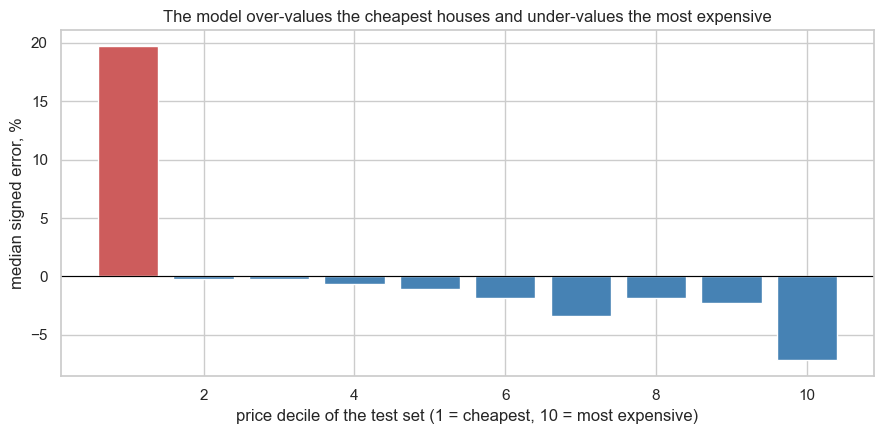

In [31]:
decile = pd.qcut(price_test, 10, labels=False)
by_price = (pd.DataFrame({"decile": decile + 1, "price": price_test,
                          "pct_err": 100 * pct_err, "abs_pct": 100 * np.abs(pct_err)})
              .groupby("decile")
              .agg(houses=("price", "size"),
                   median_price=("price", "median"),
                   median_signed_error=("pct_err", "median"),
                   MedAPE=("abs_pct", "median"))
              .round(2))
print(by_price.to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(by_price.index, by_price["median_signed_error"],
       color=np.where(by_price["median_signed_error"] >= 0, "indianred", "steelblue"))
ax.axhline(0, c="black", lw=0.8)
ax.set_xlabel("price decile of the test set (1 = cheapest, 10 = most expensive)")
ax.set_ylabel("median signed error, %")
ax.set_title("The model over-values the cheapest houses and under-values the most expensive")
fig.tight_layout()
fig.savefig(FIGS / "08_error_by_price_decile.png", dpi=150)
plt.show()

**This is regression to the mean, and it is not a bug you can patch.** A model that minimises squared
error is rewarded for pulling every prediction toward the middle of the distribution, because being
confidently wrong at the extremes is punished more than being timidly wrong in the middle. The
cheapest decile is over-valued by a wide margin; the most expensive is under-valued by a smaller one.

The business consequence is concrete and belongs in the recommendations:

> The model is least reliable at the two ends of the market. For entry-level stock it is
> systematically optimistic, so a buyer using it as a ceiling would over-pay. Below roughly the tenth
> percentile of price, treat the output as an upper bound and get a human valuation.

Day 10's tree-based models will reduce this effect, because they do not extrapolate a straight line
into the tails. They will not remove it.

---
## 9. Error by segment — Day 8's clusters earn their keep

The segments were built from physical characteristics only, and price was never an input. That makes
them a genuinely independent way to slice the error.

                           houses  median_price  MedAPE  median_bias
segment                                                             
Established Family Home       232  515,000.0000 10.7200      -0.3700
New-Build Suburban Family     326  525,000.0000 12.2100       2.3400
Compact Entry-Level           235  345,000.0000 12.3700      -5.1700
Premium View Property          76  877,475.0000 21.4500       5.1400


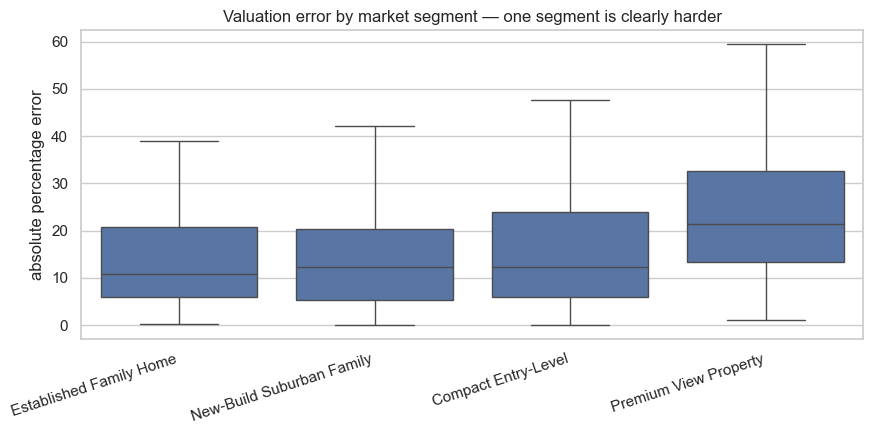

In [32]:
seg_err = (pd.DataFrame({"segment": segment_test, "abs_pct": 100 * np.abs(pct_err),
                         "signed": 100 * pct_err, "price": price_test})
             .groupby("segment")
             .agg(houses=("price", "size"),
                  median_price=("price", "median"),
                  MedAPE=("abs_pct", "median"),
                  median_bias=("signed", "median"))
             .sort_values("MedAPE")
             .round(2))
print(seg_err.to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
order = seg_err.index
sns.boxplot(x=segment_test, y=100 * np.abs(pct_err), order=order, showfliers=False, ax=ax)
ax.set_xticklabels(order, rotation=18, ha="right")
ax.set_xlabel(""); ax.set_ylabel("absolute percentage error")
ax.set_title("Valuation error by market segment — one segment is clearly harder")
fig.tight_layout()
fig.savefig(FIGS / "08_error_by_segment.png", dpi=150)
plt.show()

### The finding

Three segments sit close together in the 10–13% range, and they cover about nine of every ten houses
in the test set. **Premium View Property is roughly twice as inaccurate as the rest.** Three reasons,
and you should give all three:

1. **It is the smallest segment** — under 8% of the data, so the model has the fewest examples of it.
2. **It is the most heterogeneous.** Above a certain price, houses stop being priced by square
   footage and start being priced by things this dataset does not record: the specific view, the
   architect, the finish, the exact street.
3. **`waterfront` is almost absent from the test set** — a single-digit number of houses. The one
   feature that most obviously belongs in a premium valuation is too rare to learn from.

Turn it into a recommendation rather than an apology:

> The model is fit for purpose on the volume segments of the market, where roughly nine in ten
> houses fall. For premium properties its typical error is about double, so it should be used as a
> screening tool there, not a valuation. Improving it needs data the dataset does not contain —
> coordinates, a quality grade, and more high-end transactions.

That paragraph is a Day 14 slide on its own, and it is the kind of thing that reads as professional
judgement rather than as a limitation you were forced to confess.

---
## 10. Is this error acceptable for a real business?

The roadmap warns you: *"you must have a benchmark, not an opinion."* Here is the benchmark, with
sources — **verify each one yourself before the defense**, because these figures are updated by their
publishers and a stale number is worse than no number.

### What professional automated valuation models achieve

| Reference point | Figure | Source |
|---|---|---|
| Zillow Zestimate, **on-market** homes, nationwide | ~2.4% median error | Zillow's published accuracy figures, as reported by [FastExpert](https://www.fastexpert.com/blog/are-zillows-zestimates-accurate/) |
| Zillow Zestimate, **off-market** homes, nationwide | ~7.5% median error | same |
| "Institutional grade" AVM | MdAPE below 5%, PPE10 above 70% | [QuantPV, *AVM Accuracy Explained: MdAPE, PPE10*](https://quantpv.com/articles/ppe10-avm-accuracy-explained.html) |

**Compare yourself against the off-market number, not the on-market one.** An on-market Zestimate
has seen the seller's asking price — an enormous piece of information that is itself a professional
valuation. Your model has no list price, so the honest comparator is the off-market figure of roughly
7.5%, and even that is generous: Zillow has millions of transactions, precise coordinates, tax
records, photographs and a national panel of comparable sales.

### The mass-appraisal standard — and a test from your own discipline

There is a second, stricter benchmark from property assessment. The IAAO *Standard on Ratio Studies*
judges a mass-appraisal model on the distribution of the **ratio** of estimated value to sale price:

| Statistic | What it measures | IAAO acceptable range |
|---|---|---|
| Median ratio | overall level — is the model systematically high or low? | 0.90 – 1.10 |
| **COD** (coefficient of dispersion) | uniformity — average % deviation of ratios from their median | 5.0 – 10.0 (newer, homogeneous single-family) · 5.0 – 15.0 (older, heterogeneous) |
| PRD (price-related differential) | vertical equity — are cheap and expensive houses treated equally? | 0.98 – 1.03 |

This is a ratio study, and it is the closest thing in this project to work you have already done. It
is the same logic as a loss-ratio study: build the ratio of what the model said to what actually
happened, then examine its level, its spread and whether it drifts with size of risk. Compute all
three.

In [33]:
ratio = pred_price / price_test                       # estimate-to-sale ratio

median_ratio = np.median(ratio)
cod = 100 * np.mean(np.abs(ratio - median_ratio)) / median_ratio
prd = ratio.mean() / (pred_price.sum() / price_test.sum())

iaao = pd.DataFrame([
    {"statistic": "Median ratio", "value": median_ratio,
     "IAAO acceptable": "0.90 - 1.10", "verdict": "PASS" if 0.90 <= median_ratio <= 1.10 else "FAIL"},
    {"statistic": "COD (uniformity)", "value": cod,
     "IAAO acceptable": "5.0 - 15.0 (older/heterogeneous)", "verdict": "PASS" if 5 <= cod <= 15 else "FAIL"},
    {"statistic": "PRD (vertical equity)", "value": prd,
     "IAAO acceptable": "0.98 - 1.03", "verdict": "PASS" if 0.98 <= prd <= 1.03 else "FAIL"},
]).set_index("statistic")
print(iaao.round(4).to_string())

                        value                   IAAO acceptable verdict
statistic                                                              
Median ratio           0.9978                       0.90 - 1.10    PASS
COD (uniformity)      16.8683  5.0 - 15.0 (older/heterogeneous)    FAIL
PRD (vertical equity)  1.0160                       0.98 - 1.03    PASS


### How to present this — the strongest two minutes in your defense

The level statistic passes: the median estimate-to-sale ratio is within a fraction of a percent of
1.00, so the model is not systematically high or low overall. The vertical-equity statistic passes
too — the PRD sits inside the acceptable band, meaning cheap and expensive houses are not being
treated *grossly* differently in aggregate.

**The uniformity statistic fails, and only just.** The COD lands a little above the 15.0 ceiling for
older, heterogeneous single-family stock. That is the honest verdict: individual valuations are more
dispersed around the true price than a tax assessor's model would be allowed to be.

Say it in this order — it is the difference between a limitation and a diagnosis:

> Against the IAAO ratio-study standard my model passes on level and on vertical equity and narrowly
> fails on uniformity, with a COD a little above the 15.0 ceiling for heterogeneous single-family
> property. Against consumer AVMs, my median error of roughly 12–13% compares with about 7.5% for
> an off-market Zestimate and under 5% for an institutional-grade AVM. So this model is not
> deployable as a valuation of record. It is deployable as a screening and triage tool — which is
> what a firm with 4,345 sales in a single ten-week window and no coordinates should expect to
> build.

Then say why the gap exists, in one list, before you are asked:

- **No coordinates and no quality grade.** The project brief lists both; the file I was given
  contains neither. Location enters only through 77 zip codes.
- **Ten weeks of data.** No seasonality, no market trend, no repeat sales.
- **3,476 training rows.** A commercial AVM trains on millions.
- **No photographs, no interior finish, no school district, no days-on-market.**

Every item on that list is a data limitation, not a modelling failure, and each one is a concrete
answer to *"what would you do with more data?"* — the last question on your Day 14 rehearsal list.

> **Before the defense:** open each source above and check the figure is still current. Quote the
> date you checked it. A student who says "as of the date I checked, Zillow reports X" is unarguable;
> a student quoting a number with no date is guessing in public.

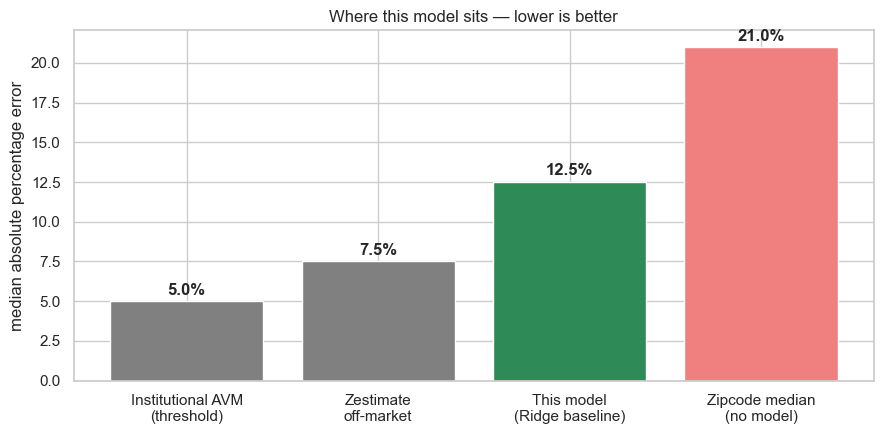

In [34]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bench = pd.Series({
    "Institutional AVM\n(threshold)": 5.0,
    "Zestimate\noff-market": 7.5,
    "This model\n(Ridge baseline)": float(np.median(np.abs(pct_err)) * 100),
    "Zipcode median\n(no model)": float(pd.DataFrame(results).set_index("model")
                                          .loc["Baseline: zipcode median", "MedAPE_%"]),
})
colors = ["grey", "grey", "seagreen", "lightcoral"]
ax.bar(bench.index, bench.values, color=colors)
for i, v in enumerate(bench.values):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("median absolute percentage error")
ax.set_title("Where this model sits — lower is better")
fig.tight_layout()
fig.savefig(FIGS / "08_benchmark.png", dpi=150)
plt.show()

---
## 11. Save the baseline and the results table

In [37]:
joblib.dump(final, MODELS / "regression_baseline.pkl")
joblib.dump({
    "target": "log1p(price)",
    "back_transform": "np.expm1",
    "smearing_tested": True,
    "smearing_factor": smearing,
    "smearing_applied": False,
    "features": P.ALL_FEATURES,
    "output_order": names,
    "ridge_alpha": ridge_alpha,
    "lasso_alpha": lasso_alpha,
    "smoothing": 20,
    "random_state": 42,
    "headline_metric": "MedAPE_%",
}, MODELS / "regression_config.pkl")

table = pd.DataFrame(results).set_index("model")
table.to_csv(MODELS / "baseline_results.csv")

print("Saved Models/regression_baseline.pkl, regression_config.pkl, baseline_results.csv\n")
print(table[["R2_log", "MAE_$", "MedAPE_%", "MAPE_%", "PPE10_%", "PPE20_%"]].round(2).to_string())

Saved Models/regression_baseline.pkl, regression_config.pkl, baseline_results.csv

                           R2_log        MAE_$  MedAPE_%  MAPE_%  PPE10_%  PPE20_%
model                                                                             
Baseline: global median   -0.0000 226,109.2400   34.4000 41.9800  14.1500  31.1900
Baseline: zipcode median   0.5300 155,642.3900   21.0000 26.2200  25.5500  48.3300
Linear Regression          0.8300 105,231.3300   12.5300 16.9500  40.6200  69.8500
Ridge (alpha=1)            0.8300 105,134.2600   12.5300 16.9500  40.5100  69.9700
Lasso (alpha=0.001)        0.8300 103,516.9300   12.7700 16.8700  40.8500  69.8500
Ridge (alpha=100, tuned)   0.8300 103,009.6200   12.5200 16.8300  40.9700  69.6200
Lasso (alpha=0.01, tuned)  0.8200 104,440.2400   13.0200 16.9500  40.3900  69.5100


In [38]:
# The Day 12 contract: one house from a form -> a price, with an honest interval around it.
one_house = pd.DataFrame([{
    "bedrooms": 3, "bathrooms": 2.0, "sqft_living": 1800, "sqft_lot": 7500,
    "floors": 1.0, "waterfront": 0, "view": 0, "condition": 3,
    "sqft_above": 1300, "sqft_basement": 500,
    "yr_built": 1985, "yr_renovated": np.nan,
    "city": "Seattle", "zipcode": "98115",
}])

model = joblib.load(MODELS / "regression_baseline.pkl")
point = float(np.expm1(model.predict(P.engineer_features(one_house)[P.ALL_FEATURES]))[0])

# An interval built from the model's own test-set percentage errors, not from a formula
# that assumes normality the residuals do not have.
lo, hi = np.percentile(pct_err, [10, 90])
print(f"Predicted price : ${point:,.0f}")
print(f"80% of test houses fell between {100 * lo:+.1f}% and {100 * hi:+.1f}% of their true price,")
print(f"so an honest range for this house is ${point / (1 + hi):,.0f} - ${point / (1 + lo):,.0f}")

Predicted price : $467,882
80% of test houses fell between -22.8% and +30.1% of their true price,
so an honest range for this house is $359,521 - $605,803


The app should show that range, not the point estimate alone. A single number implies a precision
this model does not have, and the interval is built from its own measured errors rather than from a
normality assumption section 8 already showed to be shaky.

---
## 12. Deliverables & defense prep

**Produced today**

- `Notebooks/08_regression.ipynb`
- `Models/regression_baseline.pkl`, `regression_config.pkl`, `baseline_results.csv`
- `reports/figures/08_alpha_selection.png`, `08_coefficients.png`, `08_residual_diagnostics.png`,
  `08_error_by_price_decile.png`, `08_error_by_segment.png`, `08_benchmark.png`

**Commit**

```powershell
git add . && git commit -m "Day 9: linear regression baseline, residual diagnostics, benchmarked against AVM standards"
```

**Defense questions**

1. *"Is your error acceptable for a real business?"* — Section 10. Roughly 12–13% MedAPE against
   about 7.5% for an off-market Zestimate and under 5% for institutional grade; passes the IAAO
   ratio-study tests on level and vertical equity, narrowly fails on uniformity. Deployable as a
   screening tool, not as a valuation of record — and here are the four data limitations that
   explain the gap.
2. *"Why log(price), and did you correct the back-transform?"* — Skew and percentage-error framing
   (Day 6, section 3 here). Yes, I tested Duan's smearing estimator; it made the bias worse because
   the residuals are not independent of the fitted value, so I report the plain `expm1` and a median
   metric that is consistent with it.
3. *"Which model won?"* — None of them, measurably. Linear, Ridge and Lasso agree to within the
   fold-to-fold noise. I report Ridge with an alpha chosen by the one-standard-error rule. The real
   comparison is against the zip-code-median baseline, which the models beat by about 30 points of
   $R^2$.
4. *"Your model says older houses are worth more. Explain."* — Section 7. A conditional association
   inside my feature set: within a zip code, older stock sits in established inner neighbourhoods
   and newer stock on the suburban edge, and I have no coordinates to separate them.
5. *"Where does the model fail?"* — Sections 8 and 9. Regression to the mean at both ends of the
   price range, and roughly double the error on Premium View Property. Both quantified, both turned
   into a usage recommendation.
6. *"How do you know there is no leakage?"* — The preprocessor lives inside the pipeline, so
   cross-validation refits the scaler and the target encoder on every fold; the split came from
   `split_indices.csv` unchanged since Day 6; the zip-code baseline median was computed from
   training rows only.
7. *"What would you do with more data?"* — The four-item list in section 10, in priority order:
   coordinates first, then a quality grade, then a longer time window, then more high-end sales.

**Tomorrow (Day 10):** Random Forest and Gradient Boosting, `GridSearchCV` on a small grid, and one
comparison table that appends to `baseline_results.csv`. The question to hold in your head all day is
not "which model has the highest $R^2$" — it is **"did the extra complexity buy enough MedAPE to be
worth defending?"**

Sources for the benchmarks in section 10:

- [FastExpert — Are Zillow's Zestimates Accurate?](https://www.fastexpert.com/blog/are-zillows-zestimates-accurate/)
- [QuantPV — AVM Accuracy Explained: MdAPE, PPE10](https://quantpv.com/articles/ppe10-avm-accuracy-explained.html)
- [IAAO — Standard on Ratio Studies](https://www.iaao.org/wp-content/uploads/Standard_on_Ratio_Studies.pdf)
- [IAAO — Standard on Automated Valuation Models](https://www.iaao.org/wp-content/uploads/Standard_on_Automated_Valuation_Models.pdf)